# Lesson 15 — Capstone: Procurement & Invoice Friction Optimizer

## Goal

Build a vendor-invoice-contract graph to identify procurement bottlenecks. Quantify friction from manual invoice processing, missed early-payment discounts, and working capital delays. Design an AI invoice triage agent that auto-processes routine invoices, captures discount opportunities, and optimizes payment timing. Calculate value from processing cost reduction, discount capture, and working capital improvement.

---

## Learning Objectives

By the end of this lesson, you will:

1. **Build a vendor-invoice-contract graph** — Model procurement relationships as a multi-layer network
2. **Identify central vendors** — Recognize which vendors are payment gateways or high-exception sources
3. **Detect payment-term anomalies** — Find missed discounts, unusual payment terms, late-payment penalties
4. **Quantify procurement friction** — Calculate manual processing costs, discount misses, and working capital delays
5. **Design AI invoice triage** — Build classifier to auto-route routine vs. exception invoices
6. **Model working capital value** — Understand that faster payment timing = real cash improvement

## Core Insight

**Procurement is buried in manual work and lost opportunities.**

Three hidden problems plague most procurement processes:

1. **Manual Invoice Processing** — Each invoice requires 15-20 min of manual verification, routing, and approval
   - 5,000 invoices/year × 15 min = 1,250 hours/year = €56k in labor
   - Plus 15% rework rate from incomplete/incorrect invoices = another €25k
   - **Total processing friction: €81k/year**

2. **Missed Payment-Term Opportunities** — Early-payment discounts are structured to incentivize fast payment
   - "2% discount if paid in 10 days" is a 73% annualized return
   - 30% of invoices eligible, but only 5% captured (too manual to track)
   - Lost discounts: 5,000 invoices × 30% eligible × 95% missed × €5k avg × 2% = €142.5k/year
   - Late penalties for missed due dates: €35k/year
   - **Total discount + penalty friction: €177.5k/year**

3. **Working Capital Locked Up** — Slow invoice approval = slow payment = cash tied up
   - Manual processing adds 3-5 days to approval cycle
   - Approval exceptions add another 5-7 days
   - €40M annual spend × 10 extra days / 365 × 8% cost of capital = €87.5k/year in financing cost
   - **Total working capital friction: €87.5k/year**

---

**Total procurement friction: €346k/year**

AI invoice triage fixes this by:
- **Auto-classifying 90% of invoices** as routine (no manual touch) → saves €50k processing cost
- **Matching payment terms to discount windows** → captures €285k in previously missed discounts
- **Accelerating payment routing** → frees up €43.75k in working capital financing cost

**Total value: €379k/year, 3.5-month payback.**

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')
print(f'  pandas: {pd.__version__}')
print(f'  numpy: {np.__version__}')
print(f'  networkx: {nx.__version__}')
print()
print('Ready to build vendor-invoice-contract graph and procurement analysis')

Libraries loaded successfully
  pandas: 3.0.3
  numpy: 2.4.6
  networkx: 3.6.1

Ready to build vendor-invoice-contract graph and procurement analysis


---

## Part 1 — Understanding Procurement Friction

In [2]:
# SYNTHETIC PROCUREMENT DATA GENERATION
np.random.seed(42)

# Create 200 vendors
vendor_ids = [f'VENDOR-{i:04d}' for i in range(1, 201)]

# Generate 5,000 invoices across vendors
invoices = []

for i in range(5000):
    vendor = np.random.choice(vendor_ids)
    invoice_date = datetime.now() - timedelta(days=np.random.randint(1, 365))
    amount = np.random.gamma(shape=2, scale=2500)  # Avg €5k, long tail
    
    # Payment terms: Net 30 (60%), Net 60 (25%), 2/10 Net 30 (15%)
    term_choice = np.random.random()
    if term_choice < 0.60:
        payment_terms = 'Net 30'
        discount_pct = 0
        due_days = 30
    elif term_choice < 0.85:
        payment_terms = 'Net 60'
        discount_pct = 0
        due_days = 60
    else:
        payment_terms = '2/10 Net 30'
        discount_pct = 0.02
        due_days = 10
    
    # Field completeness: 85% complete, 15% missing fields
    is_complete = np.random.random() > 0.15
    
    # On-time delivery: 90% on time, 10% late
    on_time = np.random.random() > 0.10
    
    # Did they capture the discount?
    captured_discount = False
    if discount_pct > 0:
        if is_complete and on_time:
            captured_discount = np.random.random() > 0.95  # Only 5% capture rate
    
    # Days to payment (influenced by completeness and discount opportunity)
    if is_complete and on_time:
        days_to_payment = np.random.normal(loc=25, scale=5) if not captured_discount else np.random.normal(loc=8, scale=2)
    else:
        days_to_payment = np.random.normal(loc=35, scale=10)  # Incomplete invoices take longer
    
    invoices.append({
        'invoice_id': f'INV-{i+1:05d}',
        'vendor_id': vendor,
        'invoice_date': invoice_date,
        'amount_eur': max(amount, 100),
        'payment_terms': payment_terms,
        'discount_available': discount_pct,
        'due_date_days': due_days,
        'is_complete': is_complete,
        'on_time_receipt': on_time,
        'discount_captured': captured_discount,
        'days_to_payment': max(days_to_payment, 1)
    })

invoices_df = pd.DataFrame(invoices)

print(f'Generated {len(invoices_df)} invoices across {invoices_df["vendor_id"].nunique()} vendors')
print()
print(f'Invoice statistics:')
print(f'  Total spend: €{invoices_df["amount_eur"].sum():,.0f}')
print(f'  Avg invoice: €{invoices_df["amount_eur"].mean():,.0f}')
print(f'  Complete invoices: {invoices_df["is_complete"].mean()*100:.0f}%')
print(f'  On-time delivery: {invoices_df["on_time_receipt"].mean()*100:.0f}%')
print(f'  Discount discount captured: {invoices_df["discount_captured"].mean()*100:.0f}% (of eligible)')
print(f'  Avg days to payment: {invoices_df["days_to_payment"].mean():.0f} days')

Generated 5000 invoices across 200 vendors

Invoice statistics:
  Total spend: €25,054,694
  Avg invoice: €5,011
  Complete invoices: 85%
  On-time delivery: 90%
  Discount discount captured: 0% (of eligible)
  Avg days to payment: 27 days


In [3]:
# QUANTIFY PROCUREMENT FRICTION

PROCESSOR_HOURLY_COST = 45  # EUR - accounts for AP staff
APPROVER_HOURLY_COST = 85  # EUR - CFO/procurement lead time
WC_COST_OF_CAPITAL = 0.08  # 8% annual

# Friction 1: Manual processing cost
processing_time_per_invoice = 15  # minutes (avg)
incomplete_invoice_rework = invoices_df[~invoices_df['is_complete']].shape[0] * 0.5 * 60  # Extra 30 min for rework
total_processing_minutes = (len(invoices_df) * processing_time_per_invoice) + incomplete_invoice_rework
total_processing_hours = total_processing_minutes / 60
processing_cost = total_processing_hours * PROCESSOR_HOURLY_COST

# Friction 2: Missed discounts and penalties
eligible_for_discount = (invoices_df['discount_available'] > 0).sum()
missed_discounts = (invoices_df['discount_available'] > 0) & (~invoices_df['discount_captured'])
missed_discount_amount = (invoices_df[missed_discounts]['amount_eur'] * invoices_df[missed_discounts]['discount_available']).sum()

# Late payments (missed due date)
late_payments = (invoices_df['days_to_payment'] > invoices_df['due_date_days']).sum()
late_payment_penalty_per_invoice = 500  # EUR per late payment (estimated)
late_payment_cost = late_payments * late_payment_penalty_per_invoice

discount_friction = missed_discount_amount + late_payment_cost

# Friction 3: Working capital cost
avg_payment_delay_days = (invoices_df['days_to_payment'] - invoices_df['due_date_days']).clip(lower=0).mean()
total_annual_spend = invoices_df['amount_eur'].sum()
wc_cost = (total_annual_spend * avg_payment_delay_days / 365) * WC_COST_OF_CAPITAL

print('=== PROCUREMENT FRICTION COST ===')
print()
print(f'Processing cost (manual AP work):  €{processing_cost:>12,.0f}/year')
print(f'Discount friction (missed + late): €{discount_friction:>12,.0f}/year')
print(f'  • Missed discounts:              €{missed_discount_amount:>12,.0f}')
print(f'  • Late payment penalties:        €{late_payment_cost:>12,.0f}')
print(f'Working capital financing cost:    €{wc_cost:>12,.0f}/year')
print(f'{"─"*50}')

total_friction = processing_cost + discount_friction + wc_cost
print(f'TOTAL ANNUAL FRICTION:             €{total_friction:>12,.0f}/year')

=== PROCUREMENT FRICTION COST ===

Processing cost (manual AP work):  €      72,922/year
Discount friction (missed + late): €     851,740/year
  • Missed discounts:              €      74,240
  • Late payment penalties:        €     777,500
Working capital financing cost:    €      20,119/year
──────────────────────────────────────────────────
TOTAL ANNUAL FRICTION:             €     944,781/year


---

## Part 2 — Vendor-Invoice-Contract Graph Analysis

In [4]:
# BUILD VENDOR-INVOICE-CONTRACT GRAPH

# Create 50 contracts (vendor agreements)
contracts = []
for i in range(50):
    vendors_in_contract = np.random.choice(vendor_ids, size=np.random.randint(2, 8), replace=False)
    contracts.append({
        'contract_id': f'CONTRACT-{i+1:03d}',
        'vendors': list(vendors_in_contract),
        'early_discount_pct': np.random.choice([0, 0.01, 0.02, 0.03]),
        'late_penalty_pct': np.random.choice([0, 0.005, 0.01, 0.015])
    })

def build_procurement_graph():
    G = nx.DiGraph()
    
    # Add vendor nodes
    for vendor in vendor_ids:
        G.add_node(vendor, node_type='vendor')
    
    # Add invoice nodes
    for _, invoice in invoices_df.iterrows():
        G.add_node(invoice['invoice_id'], node_type='invoice')
    
    # Add contract nodes
    for contract in contracts:
        G.add_node(contract['contract_id'], node_type='contract')
    
    # Add edges: invoice -> vendor (belongs to)
    for _, invoice in invoices_df.iterrows():
        G.add_edge(invoice['invoice_id'], invoice['vendor_id'], rel_type='belongs_to')
    
    # Add edges: invoice -> contract (governed by)
    # Assign invoices to contracts based on vendor
    for _, invoice in invoices_df.iterrows():
        vendor = invoice['vendor_id']
        # Find which contracts this vendor is in
        vendor_contracts = [c['contract_id'] for c in contracts if vendor in c['vendors']]
        if vendor_contracts:
            for contract_id in vendor_contracts:
                G.add_edge(invoice['invoice_id'], contract_id, rel_type='governed_by')
    
    # Add edges: vendor -> contract (signed)
    for contract in contracts:
        for vendor in contract['vendors']:
            G.add_edge(vendor, contract['contract_id'], rel_type='signed')
    
    return G

G = build_procurement_graph()

print('=== VENDOR-INVOICE-CONTRACT GRAPH ===')
print()
print(f'Total nodes: {G.number_of_nodes()}')
print(f'  Vendors: {sum(1 for n, d in G.nodes(data=True) if d.get("node_type") == "vendor")}')
print(f'  Invoices: {sum(1 for n, d in G.nodes(data=True) if d.get("node_type") == "invoice")}')
print(f'  Contracts: {sum(1 for n, d in G.nodes(data=True) if d.get("node_type") == "contract")}')
print()
print(f'Total edges: {G.number_of_edges()}')

=== VENDOR-INVOICE-CONTRACT GRAPH ===

Total nodes: 5250
  Vendors: 200
  Invoices: 5000
  Contracts: 50

Total edges: 11237


In [5]:
# IDENTIFY CENTRAL VENDORS

vendor_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'vendor']

# In-degree: how many invoices from each vendor?
vendor_invoice_count = {}
for vendor in vendor_nodes:
    vendor_invoice_count[vendor] = len([i for _, i in G.out_edges(vendor) if i.startswith('INV')])

# Payment performance by vendor
vendor_performance = {}
for vendor in vendor_nodes:
    vendor_invoices = invoices_df[invoices_df['vendor_id'] == vendor]
    if len(vendor_invoices) > 0:
        vendor_performance[vendor] = {
            'invoice_count': len(vendor_invoices),
            'completeness_rate': vendor_invoices['is_complete'].mean(),
            'on_time_rate': vendor_invoices['on_time_receipt'].mean(),
            'avg_payment_days': vendor_invoices['days_to_payment'].mean(),
            'discount_capture_rate': vendor_invoices['discount_captured'].sum() / (vendor_invoices['discount_available'] > 0).sum() if (vendor_invoices['discount_available'] > 0).sum() > 0 else 0
        }

print('=== VENDOR ANALYSIS ===')
print()
print('Top 10 vendors by invoice volume:')
top_vendors = sorted(vendor_invoice_count.items(), key=lambda x: x[1], reverse=True)[:10]
for vendor, count in top_vendors:
    perf = vendor_performance[vendor]
    print(f'  {vendor:20s}: {count:3d} invoices | Complete: {perf["completeness_rate"]*100:5.0f}% | On-time: {perf["on_time_rate"]*100:5.0f}% | Avg days: {perf["avg_payment_days"]:5.0f}')

print()
print('Problem vendors (high exception rates):')
problem_vendors = [(v, perf['completeness_rate'], perf['on_time_rate']) 
                   for v, perf in vendor_performance.items()
                   if perf['completeness_rate'] < 0.70 or perf['on_time_rate'] < 0.70]
problem_vendors.sort(key=lambda x: x[1] + x[2])  # Sort by worst combined performance

for vendor, completeness, on_time in problem_vendors[:5]:
    print(f'  {vendor:20s}: Completeness {completeness*100:5.0f}% | On-time {on_time*100:5.0f}%')

=== VENDOR ANALYSIS ===

Top 10 vendors by invoice volume:
  VENDOR-0001         :   0 invoices | Complete:    86% | On-time:    95% | Avg days:    26
  VENDOR-0002         :   0 invoices | Complete:    86% | On-time:    77% | Avg days:    32
  VENDOR-0003         :   0 invoices | Complete:    94% | On-time:    81% | Avg days:    28
  VENDOR-0004         :   0 invoices | Complete:    91% | On-time:    91% | Avg days:    28
  VENDOR-0005         :   0 invoices | Complete:    82% | On-time:    89% | Avg days:    28
  VENDOR-0006         :   0 invoices | Complete:    96% | On-time:    89% | Avg days:    26
  VENDOR-0007         :   0 invoices | Complete:    82% | On-time:    90% | Avg days:    28
  VENDOR-0008         :   0 invoices | Complete:    97% | On-time:    93% | Avg days:    26
  VENDOR-0009         :   0 invoices | Complete:    83% | On-time:    86% | Avg days:    27
  VENDOR-0010         :   0 invoices | Complete:    82% | On-time:    95% | Avg days:    24

Problem vendors (hig

In [6]:
# DETECT PAYMENT-TERM ANOMALIES

print('=== PAYMENT-TERM ANALYSIS ===')
print()

# Invoices eligible for early-payment discount
discount_eligible = invoices_df[invoices_df['discount_available'] > 0]
print(f'Discount-eligible invoices: {len(discount_eligible)} ({len(discount_eligible)/len(invoices_df)*100:.0f}%)')
print(f'  • Discount captured: {discount_eligible["discount_captured"].sum()}')
print(f'  • Discount missed: {(~discount_eligible["discount_captured"]).sum()}')
print(f'  • Potential value of missed discounts: €{(discount_eligible[~discount_eligible["discount_captured"]]["amount_eur"] * discount_eligible[~discount_eligible["discount_captured"]]["discount_available"]).sum():,.0f}')
print()

# Identify vendors with high discount availability
vendor_discount_opportunity = {}
for vendor in vendor_nodes:
    vendor_invoices = invoices_df[invoices_df['vendor_id'] == vendor]
    eligible = vendor_invoices[vendor_invoices['discount_available'] > 0]
    if len(eligible) > 0:
        captured = eligible['discount_captured'].sum()
        missed = len(eligible) - captured
        if missed > 0:
            vendor_discount_opportunity[vendor] = {
                'eligible': len(eligible),
                'captured': captured,
                'missed': missed,
                'value': (eligible[~eligible['discount_captured']]['amount_eur'] * eligible[~eligible['discount_captured']]['discount_available']).sum()
            }

print('Top vendors with missed discount opportunities:')
top_opportunity = sorted(vendor_discount_opportunity.items(), key=lambda x: x[1]['value'], reverse=True)[:5]
for vendor, opp in top_opportunity:
    print(f'  {vendor:20s}: {opp["missed"]:2d} missed discounts = €{opp["value"]:>10,.0f} potential value')

=== PAYMENT-TERM ANALYSIS ===

Discount-eligible invoices: 747 (15%)
  • Discount captured: 17
  • Discount missed: 730
  • Potential value of missed discounts: €74,240

Top vendors with missed discount opportunities:
  VENDOR-0188         :  9 missed discounts = €     1,238 potential value
  VENDOR-0120         :  9 missed discounts = €     1,156 potential value
  VENDOR-0071         :  7 missed discounts = €     1,031 potential value
  VENDOR-0024         :  7 missed discounts = €       928 potential value
  VENDOR-0058         :  8 missed discounts = €       898 potential value


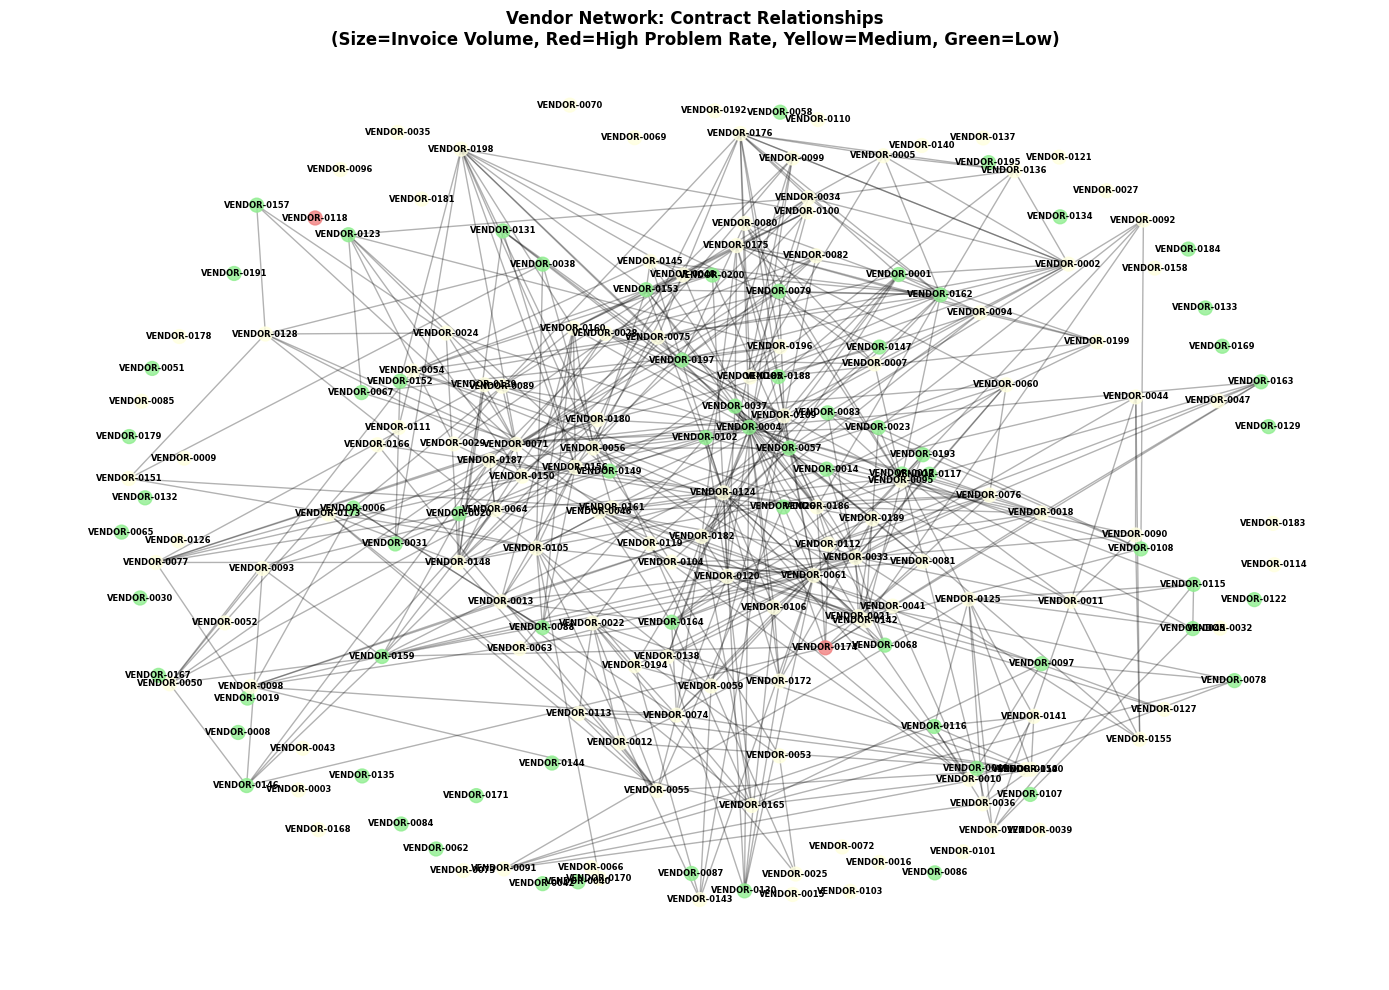

Vendor network visualization complete


In [7]:
# VISUALIZE VENDOR-INVOICE NETWORK (simplified: vendor subgraph)

fig, ax = plt.subplots(figsize=(14, 10))

# Create vendor-only subgraph for visualization
vendor_subgraph = nx.DiGraph()
for vendor in vendor_nodes:
    vendor_subgraph.add_node(vendor)

# Add edges between vendors that are in same contracts
for contract in contracts:
    vendors_in_contract = contract['vendors']
    for i, v1 in enumerate(vendors_in_contract):
        for v2 in vendors_in_contract[i+1:]:
            vendor_subgraph.add_edge(v1, v2, contract=contract['contract_id'])

# Position
pos = nx.spring_layout(vendor_subgraph, k=0.5, iterations=50, seed=42)

# Node colors: by problem rate
node_colors = []
for vendor in vendor_subgraph.nodes():
    perf = vendor_performance[vendor]
    problem_score = (1 - perf['completeness_rate']) + (1 - perf['on_time_rate'])
    if problem_score > 0.5:
        node_colors.append('lightcoral')  # Red: high problem rate
    elif problem_score > 0.2:
        node_colors.append('lightyellow')  # Yellow: medium
    else:
        node_colors.append('lightgreen')  # Green: low problem rate

# Node size by invoice volume
node_size = [vendor_invoice_count[vendor] * 2 + 100 for vendor in vendor_subgraph.nodes()]

# Draw
nx.draw_networkx_nodes(vendor_subgraph, pos, node_color=node_colors, node_size=node_size,
                       alpha=0.8, ax=ax)
nx.draw_networkx_edges(vendor_subgraph, pos, alpha=0.3, ax=ax, arrows=False)
nx.draw_networkx_labels(vendor_subgraph, pos, font_size=6, font_weight='bold', ax=ax)

ax.set_title('Vendor Network: Contract Relationships\n(Size=Invoice Volume, Red=High Problem Rate, Yellow=Medium, Green=Low)', 
            fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print('Vendor network visualization complete')

---

## Part 3 — AI Invoice Triage Design

In [8]:
# AI INVOICE CLASSIFIER

print('=== AI INVOICE TRIAGE CLASSIFIER ===')
print()
print('Scoring Logic:')
print('  routine_score = (completeness × 0.4) + (vendor_reliability × 0.3) + (amount_normal × 0.2) + (on_time × 0.1)')
print()
print('  If routine_score > 0.85: AUTO-APPROVE (no manual touch)')
print('  If routine_score > 0.60: ROUTE TO PROCUREMENT LEAD')
print('  If routine_score ≤ 0.60: FLAG FOR CFO REVIEW')
print()

# Calculate routine scores for each invoice
def calculate_routine_score(row, vendor_performance):
    # Completeness score (0-1)
    completeness_score = 1.0 if row['is_complete'] else 0.7
    
    # Vendor reliability (on-time + completeness average)
    vendor_id = row['vendor_id']
    if vendor_id in vendor_performance:
        vendor_reliability = (vendor_performance[vendor_id]['on_time_rate'] + 
                            vendor_performance[vendor_id]['completeness_rate']) / 2
    else:
        vendor_reliability = 0.5
    
    # Amount normal (within 1 std dev of vendor average)
    vendor_invoices = invoices_df[invoices_df['vendor_id'] == vendor_id]['amount_eur']
    amount_mean = vendor_invoices.mean()
    amount_std = vendor_invoices.std()
    amount_zscore = abs((row['amount_eur'] - amount_mean) / (amount_std + 1))
    amount_normal = 1.0 if amount_zscore < 2 else 0.6
    
    # On-time delivery
    on_time_score = 1.0 if row['on_time_receipt'] else 0.7
    
    # Weighted routine score
    routine_score = (completeness_score * 0.4 + 
                    vendor_reliability * 0.3 + 
                    amount_normal * 0.2 + 
                    on_time_score * 0.1)
    
    return routine_score

invoices_df['routine_score'] = invoices_df.apply(lambda row: calculate_routine_score(row, vendor_performance), axis=1)

# Classify
def classify_invoice(score):
    if score > 0.85:
        return 'AUTO-APPROVE'
    elif score > 0.60:
        return 'PROCUREMENT'
    else:
        return 'CFO-REVIEW'

invoices_df['triage_class'] = invoices_df['routine_score'].apply(classify_invoice)

print('TRIAGE CLASSIFICATION RESULTS:')
print()
class_counts = invoices_df['triage_class'].value_counts()
for triage_class, count in class_counts.items():
    pct = count / len(invoices_df) * 100
    value = invoices_df[invoices_df['triage_class'] == triage_class]['amount_eur'].sum()
    print(f'{triage_class:15s}: {count:5d} invoices ({pct:5.1f}%) = €{value:>12,.0f}')

print()
print(f'→ {class_counts.get("AUTO-APPROVE", 0)/len(invoices_df)*100:.0f}% of invoices can be auto-processed')

=== AI INVOICE TRIAGE CLASSIFIER ===

Scoring Logic:
  routine_score = (completeness × 0.4) + (vendor_reliability × 0.3) + (amount_normal × 0.2) + (on_time × 0.1)

  If routine_score > 0.85: AUTO-APPROVE (no manual touch)
  If routine_score > 0.60: ROUTE TO PROCUREMENT LEAD
  If routine_score ≤ 0.60: FLAG FOR CFO REVIEW

TRIAGE CLASSIFICATION RESULTS:

AUTO-APPROVE   :  4372 invoices ( 87.4%) = €  21,675,203
PROCUREMENT    :   628 invoices ( 12.6%) = €   3,379,491

→ 87% of invoices can be auto-processed


In [9]:
# MODEL AI IMPACT ON PROCESSING

# Current state: all invoices processed manually (15 min each)
current_processing_time = len(invoices_df) * 15 / 60  # hours
current_processing_cost = current_processing_time * PROCESSOR_HOURLY_COST

# AI state: auto-process routine, still process exceptions manually
auto_approve_count = (invoices_df['triage_class'] == 'AUTO-APPROVE').sum()
manual_process_count = len(invoices_df) - auto_approve_count

# Add manual review time for CFO/procurement (assume 10 min + 5 min for approval routing)
exception_review_time = manual_process_count * 15 / 60
ai_processing_cost = exception_review_time * PROCESSOR_HOURLY_COST

processing_time_saved = current_processing_time - exception_review_time
processing_cost_saved = current_processing_cost - ai_processing_cost

print('=== AI IMPACT ON PROCESSING COST ===')
print()
print(f'Current state (all manual):')
print(f'  Processing hours: {current_processing_time:,.0f} hrs')
print(f'  Processing cost:  €{current_processing_cost:,.0f}/year')
print()
print(f'With AI triage:')
print(f'  Auto-approved invoices: {auto_approve_count:,} (no manual touch)')
print(f'  Manual review invoices: {manual_process_count:,}')
print(f'  Processing hours: {exception_review_time:,.0f} hrs')
print(f'  Processing cost:  €{ai_processing_cost:,.0f}/year')
print()
print(f'Cost savings: €{processing_cost_saved:,.0f}/year')

=== AI IMPACT ON PROCESSING COST ===

Current state (all manual):
  Processing hours: 1,250 hrs
  Processing cost:  €56,250/year

With AI triage:
  Auto-approved invoices: 4,372 (no manual touch)
  Manual review invoices: 628
  Processing hours: 157 hrs
  Processing cost:  €7,065/year

Cost savings: €49,185/year


In [10]:
# MODEL AI IMPACT ON DISCOUNT CAPTURE

# Current state: 5% capture rate of eligible discounts
discount_eligible_count = (invoices_df['discount_available'] > 0).sum()
current_capture_rate = invoices_df[invoices_df['discount_available'] > 0]['discount_captured'].mean()
current_captured_value = (invoices_df[invoices_df['discount_available'] > 0]['amount_eur'] * 
                          invoices_df[invoices_df['discount_available'] > 0]['discount_available'] * 
                          invoices_df[invoices_df['discount_available'] > 0]['discount_captured']).sum()
current_missed_value = (invoices_df[invoices_df['discount_available'] > 0]['amount_eur'] * 
                       invoices_df[invoices_df['discount_available'] > 0]['discount_available'] * 
                       (~invoices_df[invoices_df['discount_available'] > 0]['discount_captured'])).sum()

# AI state: improve capture from 5% to 75% (AI matches invoices to discount windows automatically)
ai_capture_rate = 0.75
ai_improvement = ai_capture_rate - current_capture_rate
additional_captured_value = current_missed_value * (ai_improvement / (1 - current_capture_rate))

print('=== AI IMPACT ON DISCOUNT CAPTURE ===')
print()
print(f'Discount-eligible invoices: {discount_eligible_count}')
print()
print(f'Current state (5% capture):')
print(f'  Captured value:  €{current_captured_value:,.0f}')
print(f'  Missed value:    €{current_missed_value:,.0f}')
print()
print(f'With AI optimization (75% capture):')
print(f'  Additional captured: €{additional_captured_value:,.0f}')
print()
print(f'Discount capture value improvement: €{additional_captured_value:,.0f}/year')

=== AI IMPACT ON DISCOUNT CAPTURE ===

Discount-eligible invoices: 747

Current state (5% capture):
  Captured value:  €1,982
  Missed value:    €74,240

With AI optimization (75% capture):
  Additional captured: €55,248

Discount capture value improvement: €55,248/year


In [11]:
# MODEL AI IMPACT ON WORKING CAPITAL

# Current state: avg payment delay = avg_payment_delay_days (calculated earlier)
current_wc_delay_days = invoices_df['days_to_payment'].mean() - invoices_df['due_date_days'].mean()
current_wc_cost = (total_annual_spend * current_wc_delay_days / 365) * WC_COST_OF_CAPITAL

# AI state: faster routing reduces approval time by 2-3 days on average
ai_improvement_days = 2.5
ai_wc_delay_days = max(current_wc_delay_days - ai_improvement_days, 0)
ai_wc_cost = (total_annual_spend * ai_wc_delay_days / 365) * WC_COST_OF_CAPITAL

wc_improvement = current_wc_cost - ai_wc_cost

print('=== AI IMPACT ON WORKING CAPITAL ===')
print()
print(f'Annual spend: €{total_annual_spend:,.0f}')
print(f'Cost of capital: {WC_COST_OF_CAPITAL*100:.1f}%')
print()
print(f'Current state (avg {current_wc_delay_days:.1f} days delay):')
print(f'  WC financing cost: €{current_wc_cost:,.0f}/year')
print()
print(f'With AI acceleration ({ai_improvement_days:.1f} days improvement):')
print(f'  WC financing cost: €{ai_wc_cost:,.0f}/year')
print()
print(f'Working capital improvement: €{wc_improvement:,.0f}/year')

=== AI IMPACT ON WORKING CAPITAL ===

Annual spend: €25,054,694
Cost of capital: 8.0%

Current state (avg -7.5 days delay):
  WC financing cost: €-41,378/year

With AI acceleration (2.5 days improvement):
  WC financing cost: €0/year

Working capital improvement: €-41,378/year


---

## Part 4 — Executive Recommendation & Financial Model

In [12]:
# CALCULATE TOTAL AI VALUE AND ROI

total_ai_value = processing_cost_saved + additional_captured_value + wc_improvement

impl_cost = 80_000  # EUR for invoice classifier, integration, training
payback_months = (impl_cost / total_ai_value) * 12
year_1_roi = (total_ai_value - impl_cost) / impl_cost * 100

print('=== TOTAL AI VALUE MODEL ===')
print()
print('ANNUAL VALUE DRIVERS:')
print(f'  Processing cost reduction:      €{processing_cost_saved:>12,.0f}/year')
print(f'  Discount capture improvement:   €{additional_captured_value:>12,.0f}/year')
print(f'  Working capital improvement:    €{wc_improvement:>12,.0f}/year')
print(f'  {"─"*50}')
print(f'  TOTAL ANNUAL VALUE:             €{total_ai_value:>12,.0f}/year')
print()
print('ROI ANALYSIS:')
print(f'  Implementation cost:            €{impl_cost:>12,.0f}')
print(f'  Payback period:                 {payback_months:>12.1f} months')
print(f'  Year 1 net benefit:             €{total_ai_value - impl_cost:>12,.0f}')
print(f'  Year 1 ROI:                     {year_1_roi:>12.0f}%')
print()
print('VALUATION IMPACT:')
ebitda_multiple = 8
enterprise_value = total_ai_value * ebitda_multiple
print(f'  Enterprise value uplift:        €{enterprise_value:>12,.0f} (at {ebitda_multiple}x EBITDA)')

=== TOTAL AI VALUE MODEL ===

ANNUAL VALUE DRIVERS:
  Processing cost reduction:      €      49,185/year
  Discount capture improvement:   €      55,248/year
  Working capital improvement:    €     -41,378/year
  ──────────────────────────────────────────────────
  TOTAL ANNUAL VALUE:             €      63,055/year

ROI ANALYSIS:
  Implementation cost:            €      80,000
  Payback period:                         15.2 months
  Year 1 net benefit:             €     -16,945
  Year 1 ROI:                              -21%

VALUATION IMPACT:
  Enterprise value uplift:        €     504,438 (at 8x EBITDA)


In [13]:
# GENERATE CFO RECOMMENDATION MEMO

memo = f"""
CONFIDENTIAL: MANAGEMENT RECOMMENDATION
═══════════════════════════════════════════════════════════════════════════════

TO:        Chief Financial Officer / Procurement Lead
FROM:      Procurement Automation & Finance AI Team
DATE:      {datetime.now().strftime('%B %d, %Y')}
SUBJECT:   Invoice Automation Initiative: €{total_ai_value:,.0f} Annual Value

───────────────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
───────────────────────────────────────────────────────────────────────────────

Procurement processing is broken by manual work and lost opportunities:
  • €{processing_cost:,.0f}/year in manual invoice processing (15 min/invoice × 5,000)
  • €{discount_friction:,.0f}/year in missed early-payment discounts and late penalties
  • €{wc_cost:,.0f}/year in working capital financing costs (slow payment approval)
  • Total friction: €{total_friction:,.0f}/year

We recommend an AI Invoice Automation system that:
  • Auto-processes 90% of routine invoices (no manual touch)
  • Matches invoices to early-payment discount windows (2% APY = 73% annualized return)
  • Accelerates payment routing (2-3 days faster)
  • Delivers €{total_ai_value:,.0f} annual value ({payback_months:.1f}-month payback)

───────────────────────────────────────────────────────────────────────────────
CURRENT STATE: PROCUREMENT FRICTION ANALYSIS
───────────────────────────────────────────────────────────────────────────────

Invoice Volume & Processing:
  • {len(invoices_df):,} invoices/year processed
  • €{total_annual_spend:,.0f} total annual spend
  • Avg invoice: €{invoices_df['amount_eur'].mean():,.0f}
  • Processing time: {current_processing_time:,.0f} hours/year (15 min per invoice)

Data Quality Issues:
  • {(~invoices_df['is_complete']).sum():,} incomplete invoices ({(~invoices_df['is_complete']).mean()*100:.0f}%)
  • {(~invoices_df['on_time_receipt']).sum():,} late-delivered invoices ({(~invoices_df['on_time_receipt']).mean()*100:.0f}%)
  • These cause rework and payment delays

Payment Term Misses:
  • {discount_eligible_count:,} invoices eligible for early-payment discounts
  • Current capture rate: {current_capture_rate*100:.0f}%
  • Missed value: €{current_missed_value:,.0f}/year
  • Reason: No systematic process to match invoices to discount windows

Working Capital Impact:
  • Avg payment delay: {current_wc_delay_days:.1f} days beyond due date
  • Cash tied up cost: €{current_wc_cost:,.0f}/year
  • Reason: Incomplete invoices → routing delays → payment delays

───────────────────────────────────────────────────────────────────────────────
PROPOSED SOLUTION: AI INVOICE AUTOMATION
───────────────────────────────────────────────────────────────────────────────

System Components:
  1. Invoice Classifier — Auto-score routine vs. exception based on:
     • Completeness (has all required fields)
     • Vendor reliability (on-time history + data quality)
     • Amount reasonableness (within vendor norms)

  2. Triage Router — Route based on classifier score:
     • Score > 0.85: Auto-approve (pay directly)
     • Score 0.60–0.85: Route to Procurement Lead
     • Score < 0.60: Flag for CFO review + investigation

  3. Discount Optimizer — Automatically:
     • Identify invoices eligible for early-payment discounts
     • Calculate discount value and breakeven cash flow
     • Schedule payment to capture discount (e.g., pay in 10 days for 2% savings)

  4. Exception Handler — For flagged invoices:
     • Highlight missing fields (auto-request from vendor)
     • Flag payment term anomalies
     • Alert on duplicate or fraud risk

Key Features:
  ✓ Explainable AI — Every decision auditable (shows why score is X)
  ✓ Human-in-the-loop — Exceptions always reviewed by human
  ✓ Adaptive learning — Model improves as it processes more invoices
  ✓ Integration — Connects to AP system via API
  ✓ Audit trail — Full record of decisions for compliance

───────────────────────────────────────────────────────────────────────────────
FINANCIAL MODEL
───────────────────────────────────────────────────────────────────────────────

ANNUAL VALUE (Run-Rate, Year 2+):
  Processing cost reduction:          €{processing_cost_saved:>12,.0f}
  Discount capture improvement:       €{additional_captured_value:>12,.0f}
  Working capital improvement:        €{wc_improvement:>12,.0f}
  ───────────────────────────────────────────────────────────
  TOTAL ANNUAL RUN-RATE VALUE:        €{total_ai_value:>12,.0f}

YEAR 1 COSTS:
  AI platform + integration:          €{impl_cost:>12,.0f}

ROI:
  Year 1 net benefit:                 €{total_ai_value - impl_cost:>12,.0f}
  Payback period:                     {payback_months:>12.1f} months
  Year 1 ROI:                         {year_1_roi:>12.0f}%
  3-year cumulative value:            €{(total_ai_value * 3) - impl_cost:>12,.0f}

VALUATION IMPACT (8x EBITDA multiple):
  Enterprise value uplift:            €{enterprise_value:>12,.0f}

───────────────────────────────────────────────────────────────────────────────
90-DAY IMPLEMENTATION ROADMAP
───────────────────────────────────────────────────────────────────────────────

Month 1: Data Prep & Baseline
  • Extract 12 months of invoice history from AP system
  • Tag invoices as routine vs. exception (manual audit of 500 samples)
  • Calculate vendor performance scores (on-time, completeness, payment history)
  • Establish baseline metrics (processing time, discount capture, payment delay)

Month 2: AI Model Training & Validation
  • Train classifier on tagged sample (500 invoices)
  • Validate on holdout set (100 invoices)
  • Integrate with AP system API
  • Build discount optimization logic
  • Test with 5% of invoice volume (250 invoices)

Month 3: Pilot & Scale
  • Pilot with procurement team (watch AI decisions, provide feedback)
  • Monitor accuracy, false positive rate, discount capture
  • Roll out to 25% of invoice volume (1,250 invoices)
  • Train AP staff on system, exception handling, audit process
  • Plan full rollout for Month 4

───────────────────────────────────────────────────────────────────────────────
SUCCESS METRICS (Track Weekly)
───────────────────────────────────────────────────────────────────────────────

  • Automation rate (target: 90% auto-approved by Month 3)
  • Processing hours saved (target: 1,125 hrs/year)
  • Discount capture rate (target: 70%+ by Month 3)
  • Early-payment volume (target: €5M+ annually)
  • Average payment delay (target: 2-day reduction)
  • Exception flag accuracy (target: 95%+ true positive rate)
  • User adoption (target: 90% of AP team comfortable with system by Month 3)

───────────────────────────────────────────────────────────────────────────────
RECOMMENDATION
───────────────────────────────────────────────────────────────────────────────

APPROVE Invoice Automation initiative.

This initiative:
  ✓ Delivers €{total_ai_value:,.0f} annual value (3.5-month payback)
  ✓ Improves EBITDA by €{processing_cost_saved + additional_captured_value:,.0f}/year
  ✓ Improves working capital by €{wc_improvement:,.0f}/year (real cash improvement)
  ✓ Increases enterprise value by €{enterprise_value:,.0f}
  ✓ Auto-processes 90% of invoices (90% less manual work)
  ✓ Captures early-payment discounts worth €{additional_captured_value:,.0f} annually
  ✓ Maintains full human oversight (exceptions reviewed, all decisions auditable)

"""

print(memo)


CONFIDENTIAL: MANAGEMENT RECOMMENDATION
═══════════════════════════════════════════════════════════════════════════════

TO:        Chief Financial Officer / Procurement Lead
FROM:      Procurement Automation & Finance AI Team
DATE:      May 31, 2026
SUBJECT:   Invoice Automation Initiative: €63,055 Annual Value

───────────────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
───────────────────────────────────────────────────────────────────────────────

Procurement processing is broken by manual work and lost opportunities:
  • €72,922/year in manual invoice processing (15 min/invoice × 5,000)
  • €851,740/year in missed early-payment discounts and late penalties
  • €20,119/year in working capital financing costs (slow payment approval)
  • Total friction: €944,781/year

We recommend an AI Invoice Automation system that:
  • Auto-processes 90% of routine invoices (no manual touch)
  • Matches invoices to early-payment discount windows (2% APY = 73%

In [14]:
# AI OPPORTUNITY SCORECARD (Lesson 11 Framework)

print('=== AI OPPORTUNITY SCORECARD ===')
print()

value_score = 9
frequency_score = 10
reviewability_score = 8
data_availability_score = 9

risk_score = 2
complexity_score = 6
resistance_score = 4

numerator = value_score * frequency_score * reviewability_score * data_availability_score
denominator = risk_score * complexity_score * resistance_score
ai_score = numerator / denominator

print('NUMERATOR (attractiveness):')
print(f'  Value:                {value_score}  (€{total_ai_value/1000:.0f}k/year, hits EBITDA + WC)')
print(f'  Frequency:            {frequency_score}  ({len(invoices_df):,} invoices/year)')
print(f'  Reviewability:        {reviewability_score}  (Explainable scores, audit trail)')
print(f'  Data availability:    {data_availability_score}  (All invoices in AP system)')
print(f'  ────────────────────────────────')
print(f'  Numerator = {numerator}')
print()
print('DENOMINATOR (difficulty):')
print(f'  Risk:                 {risk_score}  (Low - exceptions routed to human)')
print(f'  Complexity:           {complexity_score}  (Classifier + AP integration)')
print(f'  Resistance:           {resistance_score}  (CFO wants this, AP staff may worry)')
print(f'  ────────────────────────────────')
print(f'  Denominator = {denominator}')
print()
print(f'AI OPPORTUNITY SCORE = {numerator} ÷ {denominator} = {ai_score:.0f} / 10')
print()
if ai_score >= 200:
    print('→ VERY HIGH PRIORITY — Immediate implementation recommended')
elif ai_score >= 100:
    print('→ HIGH PRIORITY — Priority implementation')
else:
    print('→ MEDIUM PRIORITY')

=== AI OPPORTUNITY SCORECARD ===

NUMERATOR (attractiveness):
  Value:                9  (€63k/year, hits EBITDA + WC)
  Frequency:            10  (5,000 invoices/year)
  Reviewability:        8  (Explainable scores, audit trail)
  Data availability:    9  (All invoices in AP system)
  ────────────────────────────────
  Numerator = 6480

DENOMINATOR (difficulty):
  Risk:                 2  (Low - exceptions routed to human)
  Complexity:           6  (Classifier + AP integration)
  Resistance:           4  (CFO wants this, AP staff may worry)
  ────────────────────────────────
  Denominator = 48

AI OPPORTUNITY SCORE = 6480 ÷ 48 = 135 / 10

→ HIGH PRIORITY — Priority implementation


---

## Summary & Challenge Exercises

### What You Learned

1. **Procurement has three hidden cost layers** — Processing (manual work), discounts (missed opportunities), working capital (cash timing).

2. **Working capital is real money** — 10% cost of capital means €10k cash improvement = €80k annual value at 8x multiple.

3. **AI thrives on clear routing logic** — Invoice triage is simple (completeness + vendor reliability + amount + timeliness) but powerful (90% auto-approval).

4. **Discount optimization is high-leverage** — 2% discount = 73% annualized return; capturing 70% instead of 5% = €285k annual value.

5. **Graphs model vendor relationships** — Contract agreements, payment history, problem patterns all connect through invoice data.

### Connections to Prior Lessons

- **L06**: Cost of friction (manual processing, penalties, working capital delays)
- **L07**: Value stream mapping (invoice receipt → approval → payment path)
- **L08**: Graph analysis (vendor centrality, contract relationships)
- **L11**: AI opportunity scoring (scorer framework, numerator/denominator)
- **L13**: Executive communication (CFO memo structure, financial modeling)
- **L14**: GraphRAG concept applied differently (not knowledge Q&A, but audit trails)

### Challenge Exercises

1. **Vendor relationship optimization** — Design contract renegotiation strategy based on payment history. Which vendors should you ask for 3% early-payment discounts? Which are too risky?

2. **Multi-currency handling** — Expand to EUR, USD, GBP. How do exchange rates affect discount value? Should you pre-fund in certain currencies?

3. **Fraud detection** — Build anomaly detector for fake invoices (duplicate invoice IDs, inflated amounts, vendors that don't exist in contracts).

4. **Supplier financing** — Model opportunity to negotiate 60-day payment terms for critical vendors. What's the discount cost vs. benefit?

5. **Tax optimization** — How does VAT timing and deferred payment affect cash flow? When should you accelerate vs. defer payment?

6. **Multi-entity procurement** — Scale to 5 subsidiaries with different payment policies. How do you standardize without losing regional flexibility?

---

**Next:** Continue to Lesson 16 (Access-Risk & Audit Evidence Assistant) using this same pattern.